In [1]:
from google.colab import files
files.upload()

Saving archive (3).zip to archive (3).zip


{'archive (3).zip': b'PK\x03\x04-\x00\x00\x00\x08\x00\x91\x1d4O\x0c\xce\xf0E\xff\xff\xff\xff\xff\xff\xff\xff\x16\x00\x14\x00german_credit_data.csv\x01\x00\x10\x00\x19\xc2\x00\x00\x00\x00\x00\x00\xe2*\x00\x00\x00\x00\x00\x00\x85]\xcb\xae&\xb9m\xde\x0f0\xef\xe0\x07\xf8\x01K\xa4\xae\xcb\xc0Y\x04Y\x1c\x04p\x90}\xbb\xe7\xd8n\xc43=\xe9\xe9q\xf2\xf8\x11\xa5*\x89\xa4\xc4:\x80\xe1c\xcfT\xfd%Q\xbc\xf3#\xf5\xfa\x97\xbf\xbd\xbf\xfe\xfc\xfe\x7f\xaf\x7f\xff\xfa\x97\xd7\xbf}\xfd\xfd\xb7/\xbf\xfc\xed\xf5\xe7O\xffl\x7f\xfe\xf0\xe9\xf3\xe7\xaf\xbf\xff\xf2\xfd\xb7\xd7\x9f\xfe\xfe\xfe\xf9\xbf\xd9?y\xfd\xe9\xdb\xfbO_\xbe\xff\xe1\xd3\xcf\xfd\xff\xfd\xeb\xef\xdf>}\xff\xf2\xf5\x97\xd7\x7f\xfc\xfe\xed\xd7\xaf\xbf\xbd\xff\xf8\x83{\xa5\xfc\xfa\xf9\xd3?\xde_\xf0\xfa\xfa\xbf\xbf\xbc\xde\xfe\xe5\xf5\x8f/\xdf\xbf\xb7\xff\xef}\xaa\xaf\xf4\xfa\xf6\xe9\xa7/_\xff\xf8\x9f\xff\xf5\xe3\x0f\xfe\x05\xf0\xfa\xeb;{\xf8z\xf2\xe7\xaf?\xbd\xb7\xdf}\x7f\xc5\x1a\xfd+\x14\xf6\x0e\xbcB\x1d?\xef\xf9\x1b\xed+\xe0jzyx\xbd\xff\xf4\xfb\xe

In [2]:
!unzip "archive (3).zip"


Archive:  archive (3).zip
  inflating: german_credit_data.csv  


In [3]:
import pandas as pd

df = pd.read_csv("german_credit_data.csv")

df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,0,67,male,2,own,NaN,little,1169,6,radio/TV
1,1,22,female,2,own,little,moderate,5951,48,radio/TV
2,2,49,male,1,own,little,NaN,2096,12,education
3,3,45,male,2,free,little,little,7882,42,furniture/equipment
4,4,53,male,2,free,little,little,4870,24,car


In [4]:
df.shape

(1000, 10)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
dtypes: int64(5), object(5)
memory usage: 78.3+ KB


In [6]:
df.describe()

,Unnamed: 0,Age,Job,Credit amount,Duration
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,499.500000,35.546000,1.904000,3271.258000,20.903000
std,288.819436,11.375469,0.653614,2822.736876,12.058814
min,0.000000,19.000000,0.000000,250.000000,4.000000
25%,249.750000,27.000000,2.000000,1365.500000,12.000000
50%,499.500000,33.000000,2.000000,2319.500000,18.000000
75%,749.250000,42.000000,2.000000,3972.250000,24.000000
max,999.000000,75.000000,3.000000,18424.000000,72.000000


In [7]:
df.isnull().sum()

,0
Unnamed: 0,0
Age,0
Sex,0
Job,0
Housing,0
Saving accounts,183
Checking account,394
Credit amount,0
Duration,0
Purpose,0


In [8]:
df.drop("Unnamed: 0", axis=1, inplace=True)

In [9]:
print(df['Saving accounts'].value_counts)
print(df['Checking account'].value_counts)

<bound method IndexOpsMixin.value_counts of 0           NaN
1        little
2        little
3        little
4        little
         ...   
995      little
996      little
997      little
998      little
999    moderate
Name: Saving accounts, Length: 1000, dtype: object>
<bound method IndexOpsMixin.value_counts of 0        little
1      moderate
2           NaN
3        little
4        little
         ...   
995         NaN
996      little
997         NaN
998      little
999    moderate
Name: Checking account, Length: 1000, dtype: object>


In [10]:
df['Saving accounts']= df['Saving accounts'].fillna('unknown')
df['Checking account']= df['Checking account'].fillna('unknown')

In [12]:
df.isnull().sum()

,0
Age,0
Sex,0
Job,0
Housing,0
Saving accounts,0
Checking account,0
Credit amount,0
Duration,0
Purpose,0


In [14]:
df.groupby('Sex')['Credit amount'].mean()

,Credit amount
Sex,
female,2877.774194
male,3448.040580


In [15]:
df.groupby(pd.cut(df['Age'], bins=[18,30,45,60,100]))['Credit amount'].mean()

/tmp/ipykernel_4296/3147431957.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.cut(df['Age'], bins=[18,30,45,60,100]))['Credit amount'].mean()


,Credit amount
Age,
"(18, 30]",3174.428224
"(30, 45]",3415.821340
"(45, 60]",3187.936170
"(60, 100]",3122.066667


In [16]:
df['Purpose'].value_counts()

,count
Purpose,
car,337
radio/TV,280
furniture/equipment,181
business,97
education,59
repairs,22
domestic appliances,12
vacation/others,12


In [19]:
df.groupby("Purpose")["Credit amount"].mean().sort_values(ascending=False)

,Credit amount
Purpose,
vacation/others,8209.333333
business,4158.041237
car,3768.192878
furniture/equipment,3066.988950
education,2879.203390
repairs,2728.090909
radio/TV,2487.653571
domestic appliances,1498.000000


In [20]:
df[['Credit amount', 'Duration']].corr()

,Credit amount,Duration
Credit amount,1.000000,0.624984
Duration,0.624984,1.000000


# **Visualizations**


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Better looking plots
sns.set_style("whitegrid")

<Axes: xlabel='count', ylabel='Purpose'>

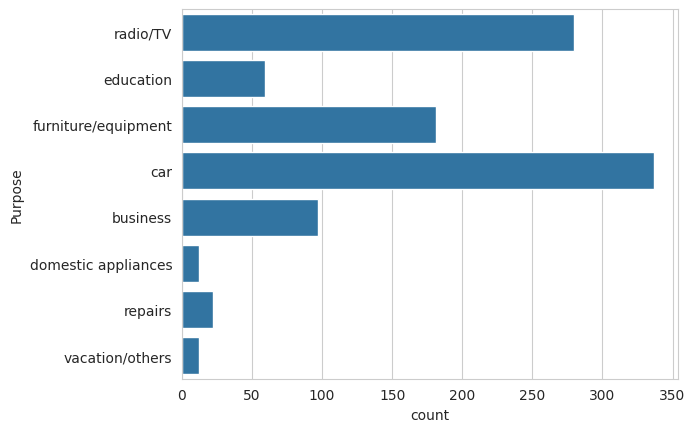

In [22]:
sns.countplot(y=df["Purpose"])

<Axes: xlabel='Credit amount', ylabel='Count'>

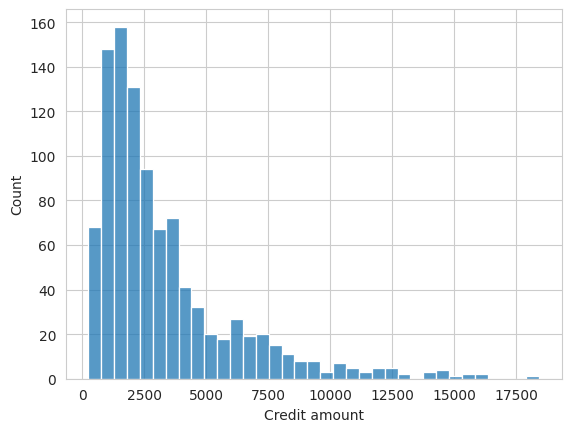

In [23]:
sns.histplot(df['Credit amount'])

<Axes: xlabel='Age', ylabel='Credit amount'>

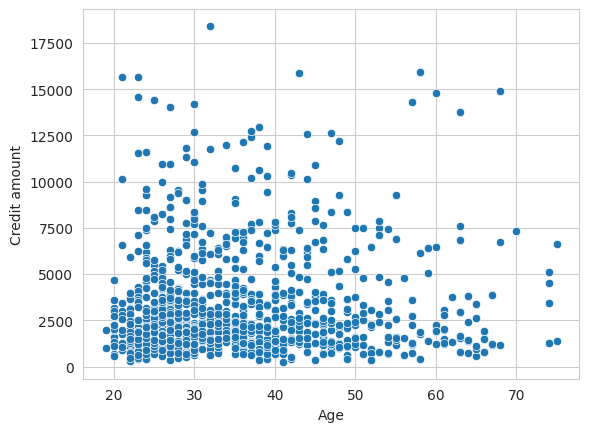

In [26]:
sns.scatterplot(
    x=df["Age"],
    y=df["Credit amount"],
    data=df
)

# Feature **Engineering**

In [51]:
df['Monthly_Burden']=(df['Credit amount']/df['Duration'])

In [52]:
df["Age_Group"]=pd.cut(df["Age"], bins=[18,30,45,60,100], labels=["young","adult","mid","senior"])

In [53]:
df["Duration_group"]=pd.cut(df["Duration"], bins=[0,12,24,36,48])

In [54]:
df.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Monthly Burden,Age Group,Duration group,Monthly_Burden,Age_Group,Duration_group
0,67,1,2,1,4,0,1169,6,5,194.833333,senior,"(0, 12]",194.833333,senior,"(0, 12]"
1,22,0,2,1,0,1,5951,48,5,123.979167,young,"(36, 48]",123.979167,young,"(36, 48]"
2,49,1,1,1,0,3,2096,12,3,174.666667,mid,"(0, 12]",174.666667,mid,"(0, 12]"
3,45,1,2,0,0,0,7882,42,4,187.666667,adult,"(36, 48]",187.666667,adult,"(36, 48]"
4,53,1,2,0,0,0,4870,24,1,202.916667,mid,"(12, 24]",202.916667,mid,"(12, 24]"


# **Clustering**

In [42]:
from sklearn.preprocessing import StandardScaler , LabelEncoder
from sklearn.cluster import KMeans

In [57]:
le = LabelEncoder()

for col in df.select_dtypes(include=["object","category"]):
  df[col]=le.fit_transform(df[col])

In [58]:
scaler=StandardScaler()

X_scaled=scaler.fit_transform(df)

In [59]:
df.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Monthly Burden,Age Group,Duration group,Monthly_Burden,Age_Group,Duration_group
0,67,1,2,1,4,0,1169,6,5,194.833333,2,0,194.833333,2,0
1,22,0,2,1,0,1,5951,48,5,123.979167,3,3,123.979167,3,3
2,49,1,1,1,0,3,2096,12,3,174.666667,1,0,174.666667,1,0
3,45,1,2,0,0,0,7882,42,4,187.666667,0,3,187.666667,0,3
4,53,1,2,0,0,0,4870,24,1,202.916667,1,1,202.916667,1,1


In [60]:
wcss = []

for k in range(1, 11):
  km=KMeans(
      n_clusters=k,
      random_state=42
  )
  km.fit(X_scaled)
  wcss.append(km.inertia_)

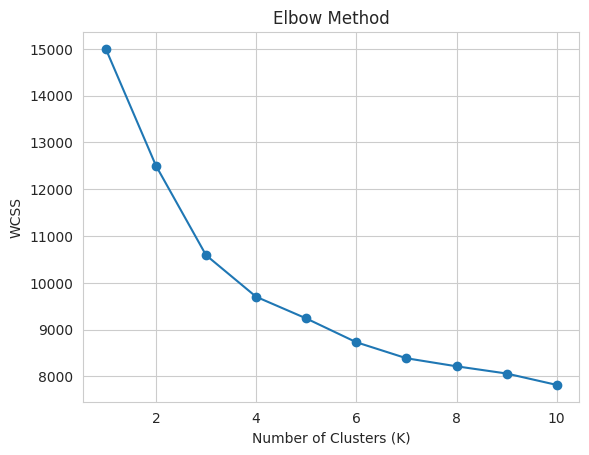

In [61]:
import matplotlib.pyplot as plt

plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [62]:
kmeans=KMeans(
    n_clusters=4,
    random_state=42
)
df["Cluster"]=kmeans.fit_predict(X_scaled)

In [64]:
df.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Monthly Burden,Age Group,Duration group,Monthly_Burden,Age_Group,Duration_group,Cluster
0,67,1,2,1,4,0,1169,6,5,194.833333,2,0,194.833333,2,0,1
1,22,0,2,1,0,1,5951,48,5,123.979167,3,3,123.979167,3,3,2
2,49,1,1,1,0,3,2096,12,3,174.666667,1,0,174.666667,1,0,1
3,45,1,2,0,0,0,7882,42,4,187.666667,0,3,187.666667,0,3,2
4,53,1,2,0,0,0,4870,24,1,202.916667,1,1,202.916667,1,1,1


In [66]:
cluster_profile = (df.groupby(df["Cluster"]).mean())

# **PCA Visualization**


In [67]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_data = pca.fit_transform(X_scaled)

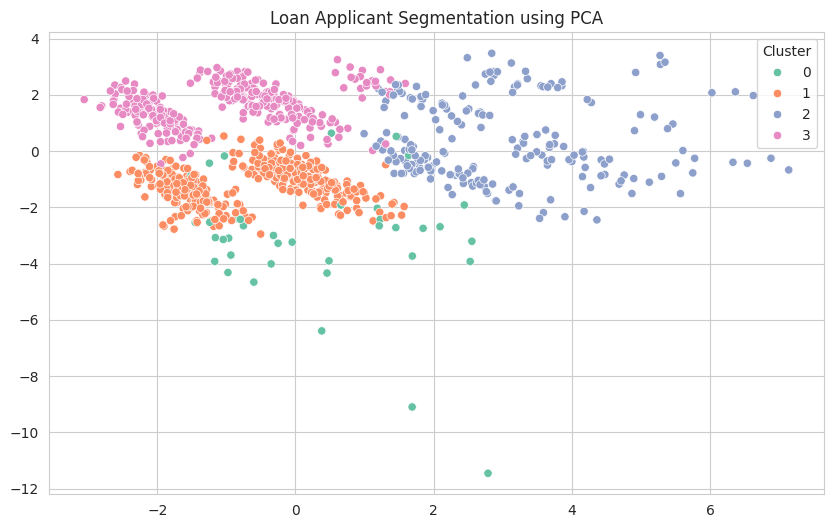

In [68]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=pca_data[:,0],
    y=pca_data[:,1],
    hue=df["Cluster"],
    palette="Set2"
)

plt.title("Loan Applicant Segmentation using PCA")
plt.show()

In [69]:
df["Cluster"] = kmeans.labels_

In [70]:
cluster_profile = df.groupby("Cluster").mean(numeric_only=True)

cluster_profile

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Monthly Burden,Age Group,Duration group,Monthly_Burden,Age_Group,Duration_group
Cluster,,,,,,,,,,,,,,,
0,42.973684,0.789474,2.236842,1.105263,1.394737,1.342105,7286.947368,12.710526,2.289474,662.626377,1.105263,0.368421,662.626377,1.105263,0.368421
1,42.433255,0.761124,1.836066,0.988290,1.208431,1.793911,2179.402810,15.611241,2.880562,149.027341,0.400468,0.536300,149.027341,0.400468,0.536300
2,35.937500,0.817308,2.153846,0.899038,1.153846,1.403846,6443.995192,39.870192,2.524038,163.024288,1.298077,2.495192,163.024288,1.298077,2.495192
3,25.440367,0.504587,1.795107,1.284404,0.905199,1.431193,2212.226300,16.700306,3.168196,137.503033,3.000000,0.648318,137.503033,3.000000,0.648318


In [71]:
df["Cluster"].value_counts()

,count
Cluster,
1,427
3,327
2,208
0,38


In [72]:
pd.crosstab(df["Cluster"], df["Purpose"])

Purpose,0,1,2,3,4,5,6,7
Cluster,,,,,,,,
0,1,23,0,2,6,4,0,2
1,33,153,4,33,65,127,9,3
2,38,71,1,14,25,49,5,5
3,25,90,7,10,85,100,8,2


In [73]:
pd.crosstab(df["Cluster"], df["Housing"])

Housing,0,1,2
Cluster,,,
0,8,18,12
1,49,334,44
2,42,145,21
3,9,216,102


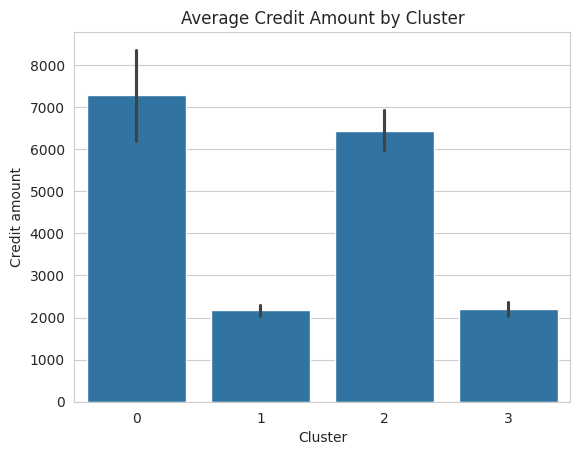

In [74]:
sns.barplot(
    x="Cluster",
    y="Credit amount",
    data=df
)

plt.title("Average Credit Amount by Cluster")
plt.show()

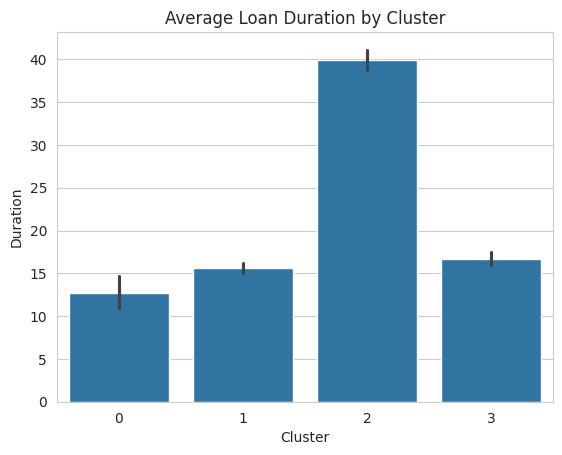

In [75]:
sns.barplot(
    x="Cluster",
    y="Duration",
    data=df
)

plt.title("Average Loan Duration by Cluster")
plt.show()

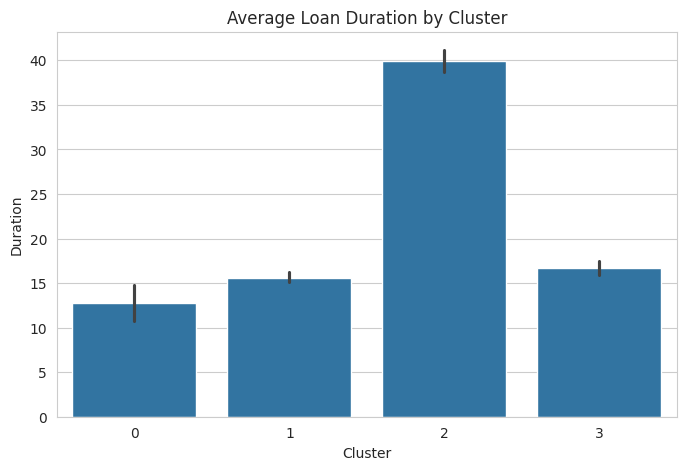

In [78]:
plt.figure(figsize=(8,5))
sns.barplot(x="Cluster", y="Duration", data=df)
plt.title("Average Loan Duration by Cluster")
plt.show()

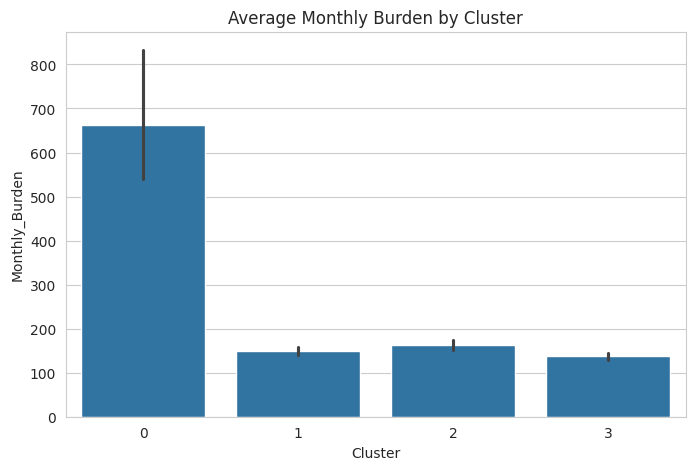

In [79]:
plt.figure(figsize=(8,5))
sns.barplot(x="Cluster", y="Monthly_Burden", data=df)
plt.title("Average Monthly Burden by Cluster")
plt.show()

# **# Final Insights and Business Recommendations**

## Overview
**bold text**
This project analyzed the financial behavior of loan applicants using exploratory data analysis, feature engineering, K-Means clustering, and PCA visualization. The objective was to identify distinct borrower segments and derive actionable business insights for financial institutions.

## Key Findings

### 1. Four Distinct Borrower Segments Were Identified

K-Means clustering grouped applicants into four meaningful borrower personas based on age, loan amount, repayment duration, housing status, and financial behavior.

### 2. Premium Borrowers

This segment consists of mature borrowers with the highest average loan amounts and the highest monthly repayment burden. Despite taking larger loans, they prefer shorter repayment periods, indicating strong repayment capacity and financial confidence.

**Business Recommendation:** Offer premium lending products, pre-approved loans, and relationship-based banking services.

### 3. Conservative Homeowners

This is the largest customer segment. Most borrowers in this group own their homes and take relatively small loans with manageable repayment schedules. Their borrowing behavior appears stable and predictable.

**Business Recommendation:** Target this segment with low-interest personal loans, insurance products, and long-term banking services.

### 4. Long-Term Financing Customers

Borrowers in this segment take large loans but prefer extended repayment durations, resulting in lower monthly burdens. These customers likely require financing for major purchases or long-term commitments.

**Business Recommendation:** Offer long-tenure financing options, mortgage-related products, and structured repayment plans.

### 5. Emerging Borrowers

This segment represents the youngest customers in the dataset. A significant portion are renters who take smaller loans and maintain relatively low monthly repayment burdens. They are likely at the beginning of their financial journey.

**Business Recommendation:** Develop credit-building programs, starter loan products, and targeted financial education initiatives.

## Financial Behavior Insights

* Homeowners generally exhibited more stable borrowing patterns.
* Younger applicants tended to request smaller loans compared to older borrowers.
* Loan amount and repayment duration showed clear relationships across borrower segments.
* Different loan purposes were concentrated within specific customer groups, indicating varying financial needs and priorities.

## Conclusion

The analysis demonstrates that loan applicants cannot be treated as a homogeneous population. By leveraging clustering techniques, financial institutions can better understand customer behavior, design personalized products, improve customer targeting, and support data-driven decision-making. The identified borrower personas provide a foundation for customer segmentation strategies and future risk assessment frameworks.
